# Probabilistic quality window by GPQR

In [ ]:
import sys
import os

import numpy as np
import torch
import pandas as pd
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

H_THRESHOLD = 1.1
PHI_THRESHOLD = 1.0

## Load data and model

In [ ]:
Xtrue = pd.read_csv("../_temp/X.csv").drop(columns="Slurry")
y = pd.read_csv("../_temp/y.csv")

In [ ]:
from scripts.model import load_model, DirectLmcMtgpqr_H, CgIndependentMtgpqr_phi

model_H, _, scaler_H = load_model(
    DirectLmcMtgpqr_H, "../model/GPQR.H.pt", device=device
)
model_phi, _, scaler_phi = load_model(
    CgIndependentMtgpqr_phi, "../model/GPQR.phi.pt", device=device
)

model_H.eval()
model_phi.eval();

### Construct prediction points

In [ ]:
N_POINTS = int(os.getenv("HEAVYEDGE_N_POINTS", 200))

g_vals = np.linspace(
    Xtrue["Gap_to_thickness_ratio"].min(),
    Xtrue["Gap_to_thickness_ratio"].max(),
    N_POINTS,
)
ca_vals = np.linspace(
    Xtrue["Capillary_number"].min(),
    Xtrue["Capillary_number"].max(),
    N_POINTS,
)
cos_vals = np.sort(Xtrue["Cos_theta"].unique())

Xpred = np.stack(np.meshgrid(g_vals, ca_vals, cos_vals, indexing="ij"), axis=-1)

### Find Delaunay regions

In [ ]:
N = Xpred.shape[-2]

simplices = []
for i in range(N):
    xtrue = Xtrue[Xtrue["Cos_theta"] == cos_vals[i]].values[:, :2]
    delaunay = Delaunay(xtrue.reshape(-1, 2))
    xpred = Xpred[:, :, i, :2]
    simplex = delaunay.find_simplex(xpred.reshape(-1, 2)) != -1
    simplices.append(simplex.reshape(Xpred.shape[:2]))
Delaunay_array = np.stack(simplices, axis=-1)

## Marginal distribution

In [ ]:
Q_H = torch.load("../model/GPQR.H.pt", map_location=device, weights_only=False)[
    "quantiles"
]
Q_phi = torch.load("../model/GPQR.phi.pt", map_location=device, weights_only=False)[
    "quantiles"
]

In [ ]:
def quantile_interpolation(q_values, q_levels, threshold):
    """Estimate P(Y <= threshold) from predicted quantiles.

    Parameters
    ----------
    q_values : (N, Q) array
        Predicted quantile values, sorted along axis=1 (no crossing).
    q_levels : (Q,) array
        Quantile levels (taus), sorted in ascending order.
    threshold : float
        The threshold value.
    """
    return _interpolate_linear(q_values, q_levels, threshold)


def _interpolate_linear(q_values, q_levels, threshold):
    idx = np.array([np.searchsorted(row, threshold) for row in q_values])
    idx_clamped = np.clip(idx, 1, len(q_levels) - 1)

    rows = np.arange(len(q_values))
    x0 = q_values[rows, idx_clamped - 1]
    x1 = q_values[rows, idx_clamped]
    y0 = q_levels[idx_clamped - 1]
    y1 = q_levels[idx_clamped]
    probs = y0 + (threshold - x0) * (y1 - y0) / (x1 - x0)

    probs = np.where(idx == 0, 0.0, probs)
    probs = np.where(idx == len(q_levels), 1.0, probs)
    return np.clip(probs, 0.0, 1.0)


def quantile_pit(q_values, q_levels, thresholds):
    """Compute PIT values P(Y <= y_i | x_i) with per-sample thresholds.

    Parameters
    ----------
    q_values : (N, Q) array
        Predicted quantile values, sorted along axis=1 (no crossing).
    q_levels : (Q,) array
        Quantile levels (taus), sorted in ascending order.
    thresholds : (N,) array
        Per-sample threshold (actual observed values).

    Returns
    -------
    (N,) array
        Estimated CDF value for each sample.
    """
    N, Q = q_values.shape
    idx = np.array([np.searchsorted(q_values[i], thresholds[i]) for i in range(N)])
    idx_clamped = np.clip(idx, 1, Q - 1)

    rows = np.arange(N)
    x0 = q_values[rows, idx_clamped - 1]
    x1 = q_values[rows, idx_clamped]
    y0 = q_levels[idx_clamped - 1]
    y1 = q_levels[idx_clamped]
    probs = y0 + (thresholds - x0) * (y1 - y0) / (x1 - x0)

    probs = np.where(idx == 0, 0.0, probs)
    probs = np.where(idx == Q, 1.0, probs)
    return np.clip(probs, 0.0, 1.0)


def predict(model, X, device, chunk_size=4096):
    pred_chunks = []
    for j in range(0, len(X), chunk_size):
        X_chunk = torch.tensor(
            X[j : j + chunk_size], dtype=torch.float32, device=device
        )
        with torch.no_grad():
            pred_chunks.append(
                model.mean_quantiles_delta(X_chunk).detach().cpu().numpy()
            )
    return np.concatenate(pred_chunks, axis=0)

In [ ]:
pred_train_H = predict(
    model_H,
    scaler_H.transform(Xtrue.values),
    device=device,
)
u_train_H = quantile_pit(pred_train_H, Q_H.cpu().numpy(), y["H"].to_numpy())
pred_grid_H = predict(
    model_H, scaler_H.transform(Xpred.reshape(-1, Xpred.shape[-1])), device
)
u_pred_H = quantile_interpolation(
    pred_grid_H, Q_H.cpu().numpy(), threshold=H_THRESHOLD
).reshape(Xpred.shape[:-1])

In [ ]:
pred_train_phi = predict(
    model_phi,
    scaler_phi.transform(Xtrue.values),
    device=device,
)
u_train_phi = quantile_pit(pred_train_phi, Q_phi.cpu().numpy(), y["phi"].to_numpy())
pred_grid_phi = predict(
    model_phi, scaler_phi.transform(Xpred.reshape(-1, Xpred.shape[-1])), device
)
u_pred_phi = quantile_interpolation(
    pred_grid_phi, Q_phi.cpu().numpy(), threshold=PHI_THRESHOLD
).reshape(Xpred.shape[:-1])

## Model joint probability

In [ ]:
def empirical_copula(u_train, u_pred, chunk_size=4096):
    """Estimate joint CDF using empirical copula.

    Parameters
    ----------
    u_train : (N, D) array
        PIT values at training points for D variables.
    u_pred : (M, D) array
        Marginal CDF values at prediction points.
    chunk_size : int
        Process predictions in chunks to limit memory.

    Returns
    -------
    (M,) array
        Estimated joint probability for each prediction point.
    """
    M = u_pred.shape[0]
    result = np.empty(M)
    for start in range(0, M, chunk_size):
        end = min(start + chunk_size, M)
        indicator = u_train[np.newaxis, :, :] <= u_pred[start:end, np.newaxis, :]
        result[start:end] = indicator.all(axis=2).mean(axis=1)
    return result

In [ ]:
u_train = np.stack((u_train_H, u_train_phi), axis=-1)
u_pred = np.stack((u_pred_H, u_pred_phi), axis=-1)
copula_values = empirical_copula(
    u_train, u_pred.reshape(-1, u_train.shape[-1])
).reshape(Xpred.shape[:-1])

## Plot

In [ ]:
N_COLORS = 8
cmap = mcolors.LinearSegmentedColormap.from_list(
    "gray_blue",
    [mcolors.to_rgba("gray", alpha=0.3), mcolors.to_rgba("tab:blue", alpha=0.8)],
    N=N_COLORS,
)

levels = np.linspace(0.0, 1.0, N_COLORS + 1)
norm = mcolors.BoundaryNorm(levels, ncolors=N_COLORS)

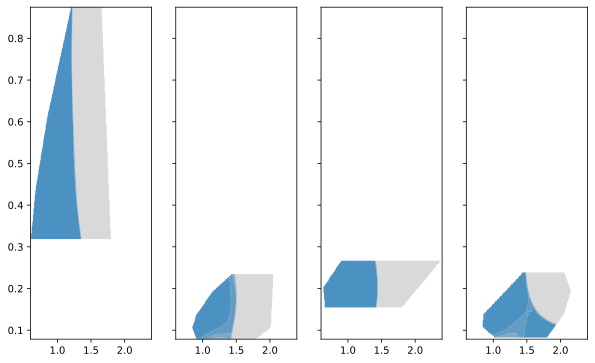

In [ ]:
fig = plt.figure(figsize=(10, 6))

if N == 1:
    axes = [fig.subplots(1, N, sharex=True, sharey=True)]
else:
    axes = fig.subplots(1, N, sharex=True, sharey=True).flatten()

for i in range(N):
    ax = axes[i]

    xpred = Xpred[:, :, i, :2]
    delaunay = Delaunay_array[:, :, i].copy()

    copula_masked = np.full_like(delaunay, np.nan, dtype=np.float64)
    copula_masked[delaunay] = copula_values[:, :, i][delaunay]

    ax.contourf(
        xpred[..., 0],
        xpred[..., 1],
        np.ma.masked_invalid(copula_masked),
        cmap=cmap,
        norm=norm,
        levels=levels,
    )